In [3]:
import glob
from pathlib import Path
import numpy as np
from scipy.interpolate import interp1d
from scipy.signal import correlate, correlation_lags

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.constants import c
import astropy.units as u
from astropy.time import Time
import chime_frb_constants as constants
# from fitburst.analysis.model import SpectrumModeler

import baseband
from baseband import vdif
from baseband_tasks.shaping import Transpose, Reshape
from baseband_tasks.functions import Square, Power
from baseband_tasks.dispersion import Dedisperse
from baseband_tasks.dm import DispersionMeasure
from baseband_tasks.combining import Concatenate

import baseband_operations as bo
import pulsarbat as pb

In [2]:
# Constants & Global Variables
SAMPLE_RATE = constants.FPGA_COUNTS_PER_SECOND * u.Hz  # samples per second (time axis sampling)
FCENS = np.linspace(775, 425, 8) # * u.MHz
S_LABELS = ['I', 'Q', 'U', 'V']
SOURCE_DIR = Path('/scratch/abernier/pulsar_data/2022_CHIME_B2111+46')
internal_folder = '20220826T064420Z_CHIME_vdif'
DM = DispersionMeasure(141.26 * u.pc / u.cm**3)

# Loading results

In [5]:
import numpy as np
import astropy.units as u
import glob
import os
import argparse

In [52]:
SOURCE = "2022_CHIME_B2111+46"
OBS_NIGHT = "20220826T064420Z"

# Info to get search results
RESULTS_DIR = f"/scratch/abernier/pulsar_data/search_results/{SOURCE}/{OBS_NIGHT}"
SETTINGS = "sliced_noDM_timeavg391_nfiles65_start160_delay-2.0_RFI1.7mean1.3std"
PARAM = "timestep"
PARAM_DIR = f"{RESULTS_DIR}/{SETTINGS}/{PARAM}/"

# Search result files
METADATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_metadata.npz")), key=len)
TIMINGS_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_timings.npz")), key=len)
DATA_FILES = sorted(glob.glob(os.path.join(PARAM_DIR, f"{PARAM}*_arrays.npz")), key=len)
NFILES = len(DATA_FILES)  # number of files to plot
DATA_FILES_UNIQUE = True   # determines if masked+normalized stokes data is the same for all values of the varied params or not
                           # True if data is unique, false if data changes with each run of param

# Save directory for figures
SOURCE_AND_NIGHT = f"{RESULTS_DIR.split('/')[-2]}/{RESULTS_DIR.split('/')[-1]}"
SAVE_FIG_DIR = f'/scratch/abernier/rm-search-Bernier-2025/figures/{SOURCE_AND_NIGHT}/{SETTINGS}/{PARAM}/'

In [70]:
param_list = []
data = {}
metadata = {}
timings = {}

for data_file, metadata_file, timings_file in zip(DATA_FILES, METADATA_FILES, TIMINGS_FILES):
    # Get parameter value from filename
    filename = os.path.basename(data_file).split('_')
    param_value = int(filename[0].split(f"{PARAM}")[1]) 
    param_list.append(param_value)

    # Load data
    with np.load(data_file, allow_pickle=True) as df:
        data_dict = {k: df[k] for k in df.files}
        data[param_value] = data_dict

    # Load metadata
    with np.load(metadata_file, allow_pickle=True) as mf:
        metadata[param_value] = mf['metadata'][0]

    # Load timings
    with np.load(timings_file, allow_pickle=True) as tf:
        timings[param_value] = tf['timings'][0]

In [74]:
data[param_list[0]].keys()

dict_keys(['full_stokes', 'time', 'freq', 'rfi_mask', 'RMSF', 'RMSF_full', 'FDF_arr', 'RM_meas_arr', 'time_slice_arr', 'lambda2_array', 'phi_array', 'cross_corr_arr', 'phi_lags'])

# normalize + mask functions

In [3]:
def flag_rfi_manual(ranges, freqs):
    """
    ranges : list of tuples
        list of (start,end) frequencies to mask
    """
    channel_mask_manual = np.full(len(freqs), False)
    
    for (start,end) in ranges:
        # Check that freqs to mask are at least particlaly contained in the frequency array
        if start > freqs[-1] or end < freqs[0]:  # completely out of range
            continue

        if start == end:
            end += freqs[1] - freqs[0]

        mask = (start <= freqs) & (freqs <= end)
        channel_mask_manual |= mask  

    return channel_mask_manual
        

def get_rfi_mask(intensity_array, mean_treshhold=2, std_threshold=5, ranges=None, freqs=None):
    """
    Flag frequency channels with anomalous statistics across time, such as unusually high
    mean or standard deviation, which may indicate RFI. Returns a boolean mask.
    
    Parameters
    ----------
    intensity_array : np.ndarray
        Normalized intensity data with shape (Ntimes, Nfreqs), where each column is a frequency channel.
    mean_threshold : float
        Threshold for the absolute value of the mean. Channels with |mean| > mean_threshold are flagged.
    std_threshold : float
        Threshold for the standard deviation. Channels with std > std_threshold are flagged.
    
    Returns
    -------
    channel_mask : np.ndarray
        Boolean array of shape (Nfreqs,) where True indicates a flagged (to be masked) frequency channel.
    """

    # Mean and std per frequency channel (avg across time)
    mean_per_channel = np.nanmean(intensity_array, axis=0)
    std_per_channel = np.nanstd(intensity_array, axis=0)

    # Normalize & compare channel means
    means_norm = (mean_per_channel - np.mean(mean_per_channel)) / np.std(mean_per_channel)
    channel_mask_mean = np.abs(means_norm) > mean_treshhold

    # Normalize & compare channel stds
    stds_norm = (std_per_channel - np.mean(std_per_channel)) / np.std(std_per_channel)
    channel_mask_std = np.abs(stds_norm) > std_threshold

    # Manually mask some channels
    cond_manual = (ranges is not None) and (freqs is not None)
    if cond_manual:
        channel_mask_manual = flag_rfi_manual(ranges, freqs)
    
    # Combine masks
    if cond_manual:
        channel_mask = channel_mask_mean | channel_mask_std | channel_mask_manual
    else:
        channel_mask = channel_mask_mean | channel_mask_std

    return channel_mask

In [50]:
def normalize_data(data_array):
    """
    Normalize data by subtracting the mean and dividing by the standard deviation,
    computed per frequency channel (over time) for each Stokes parameter.

    Parameters
    ----------
    data_array : np.ndarray
        Array of data to normalize (shape: [Nstokes, Ntimes, Nfreqs]).

    Returns
    -------
    data_normalized : np.ndarray
        Normalized array of the same shape
    """
    
    mean_per_channel = np.nanmean(data_array, axis=1, keepdims=True)
    std_per_channel = np.nanstd(data_array, axis=1, keepdims=True)
    
    return (data_array - mean_per_channel) / std_per_channel

# Nina's code

In [5]:
start_file = 160
Nfiles = 65
start_frame = start_file * 50000
number_of_frames = Nfiles * 50000  # Nfiles * Nsamples_per_file

In [6]:
# Reshape and open the files for all frequencies into readers
data_folder = Path("/scratch/abernier/pulsar_data/2022_CHIME_B2111+46")
internal_folder = '20220826T064420Z_CHIME_vdif'
my_readers = bo.get_chime_readers(data_folder, internal=internal_folder)
z = bo.lazy_read(start_frame, number_of_frames, my_readers)  # get a specific amount of data (in time) from the readers (Nframes, Nfreq, Npol)

In [7]:
# dedisperse, downsample, and get stokes
DM = pb.DispersionMeasure(141.26 * u.pc/u.cm**3)
freq_array = np.linspace(500, 400, 128*2)
ref_freq = np.max(freq_array)*u.MHz
z_dedisp = pb.coherent_dedispersion(z, DM, ref_freq=ref_freq)
# downsample!?

stokes = z_dedisp.to_stokes()
stokes = stokes.compute()

In [47]:
ntimes = stokes.shape[stokes.get_axis('time')]
time = np.linspace(0*u.s, stokes.time_length - stokes.dt, ntimes)
freq = np.linspace(stokes.min_freq, stokes.max_freq, stokes.nchan)

In [48]:
stokes.shape, freq, time

((2177965, 1024, 4),
 <Quantity [400.1953125 , 400.58631934, 400.97732619, ..., 799.41329881,
            799.80430566, 800.1953125 ] MHz>,
 <Quantity [0.00000000e+00, 2.56000000e-06, 5.12000000e-06, ...,
            5.57558272e+00, 5.57558528e+00, 5.57558784e+00] s>)

In [15]:
stokes_arr = np.array([stokes.stokesI, stokes.stokesQ, stokes.stokesU, stokes.stokesV])
time_downsamp_factor = 391
stokes_downsampled = np.array([bo.shrink_any_2(d, [time_downsamp_factor,1]) for d in stokes_arr])

In [16]:
stokes_downsampled.shape

(4, 5570, 1024)

In [73]:
# Get RFI mask using intensity data
ranges = [(529,535), (483, 483), (452,452)]
rfi_mask = get_rfi_mask(stokes_downsampled[0], mean_treshhold=2., std_threshold=1.3, ranges=ranges, freqs=freq.value)

# Normalize & mask RFI channels
stokes_norm_masked = normalize_data(stokes_downsampled.copy())
stokes_norm_masked[:,:,rfi_mask] = np.nan

/tmp/ipykernel_2975975/3227340536.py:20: RuntimeWarning: invalid value encountered in divide
  return (data_array - mean_per_channel) / std_per_channel


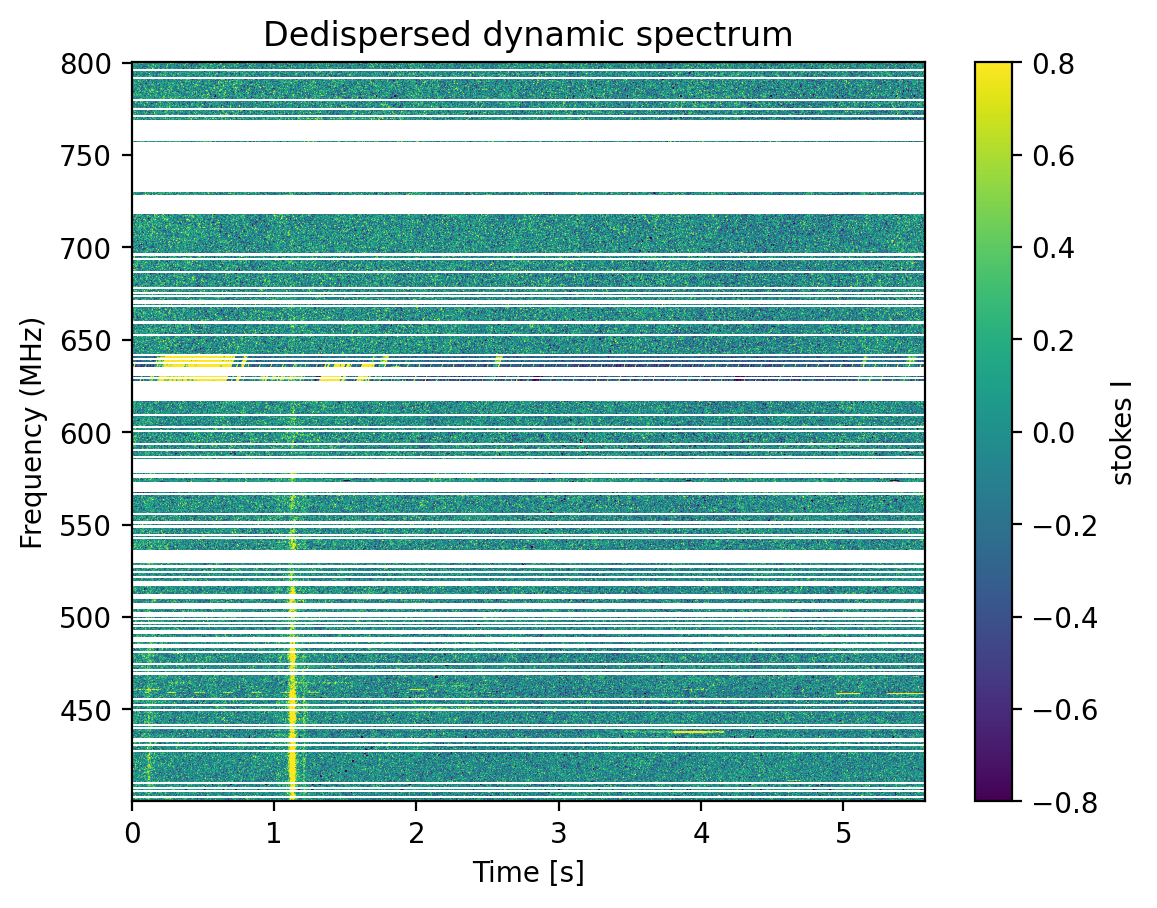

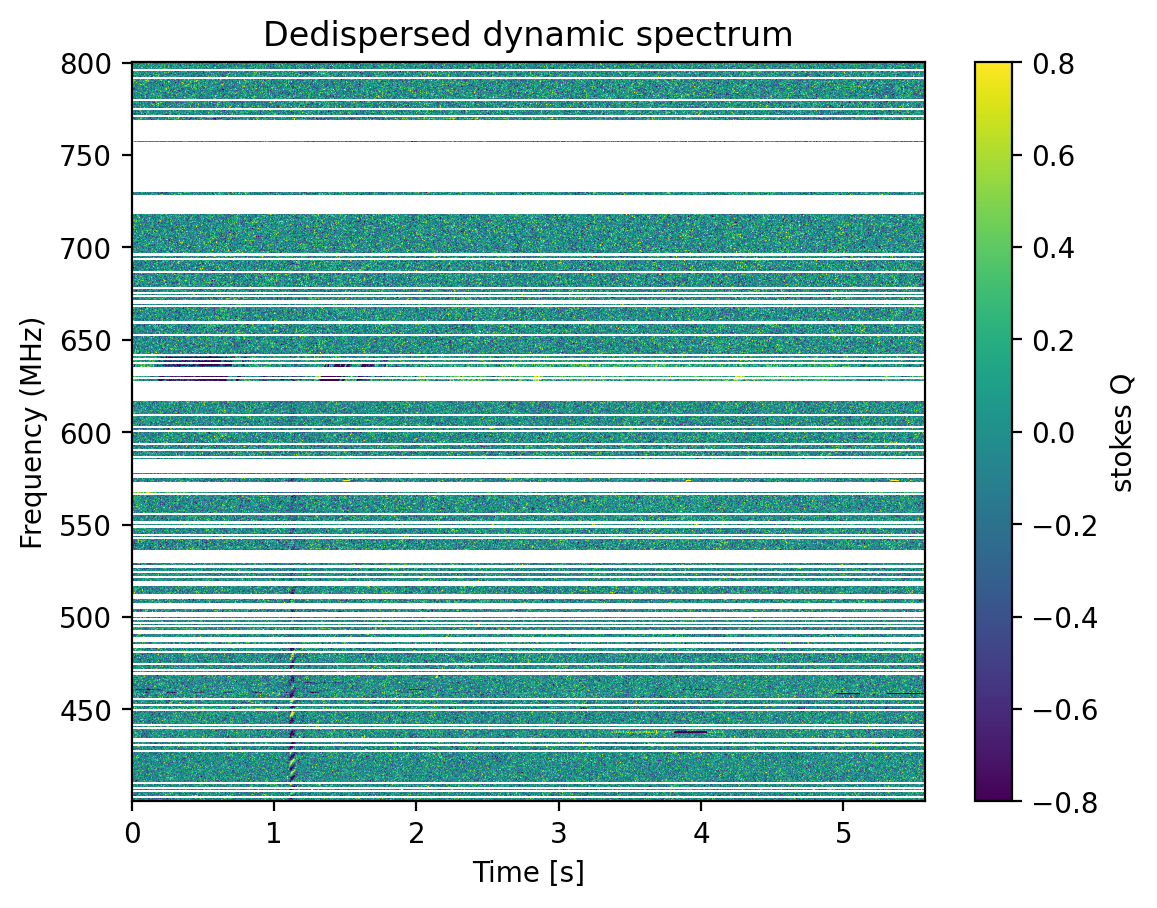

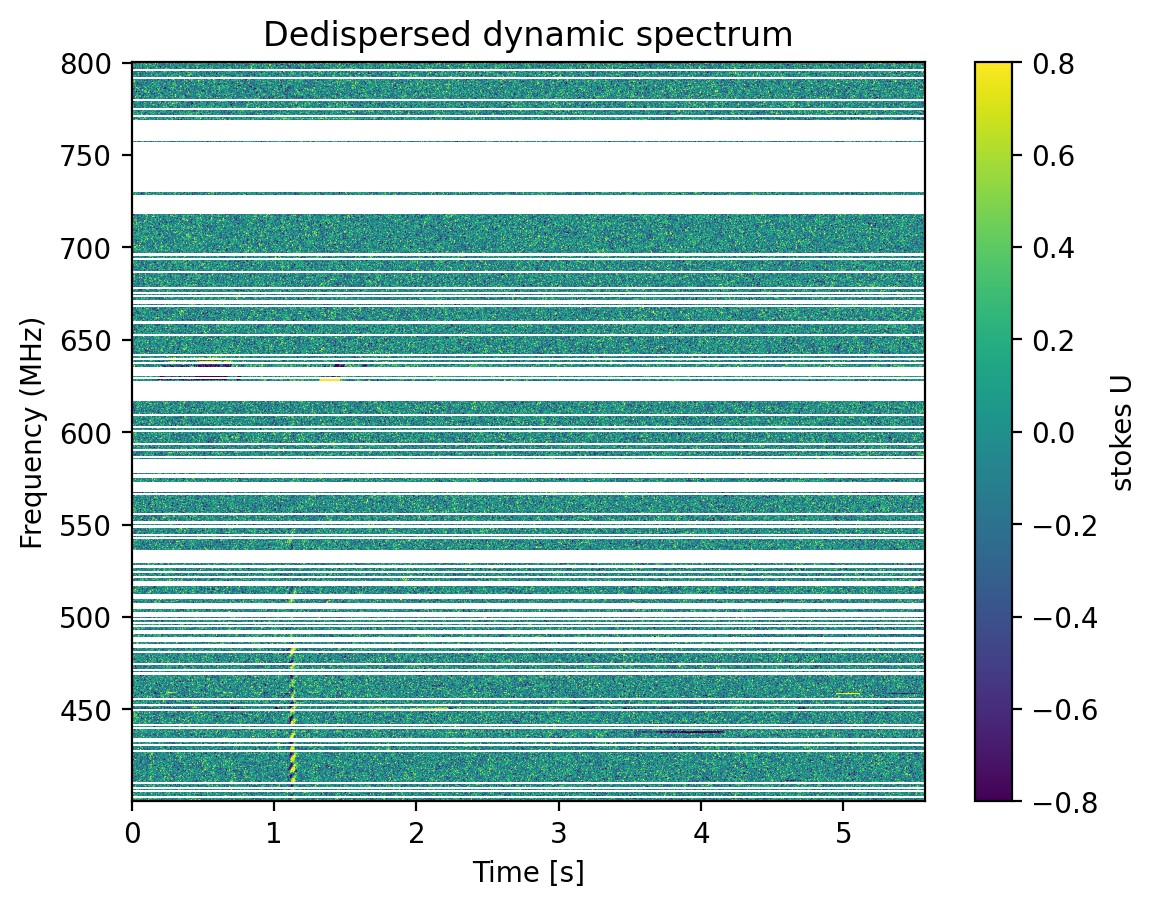

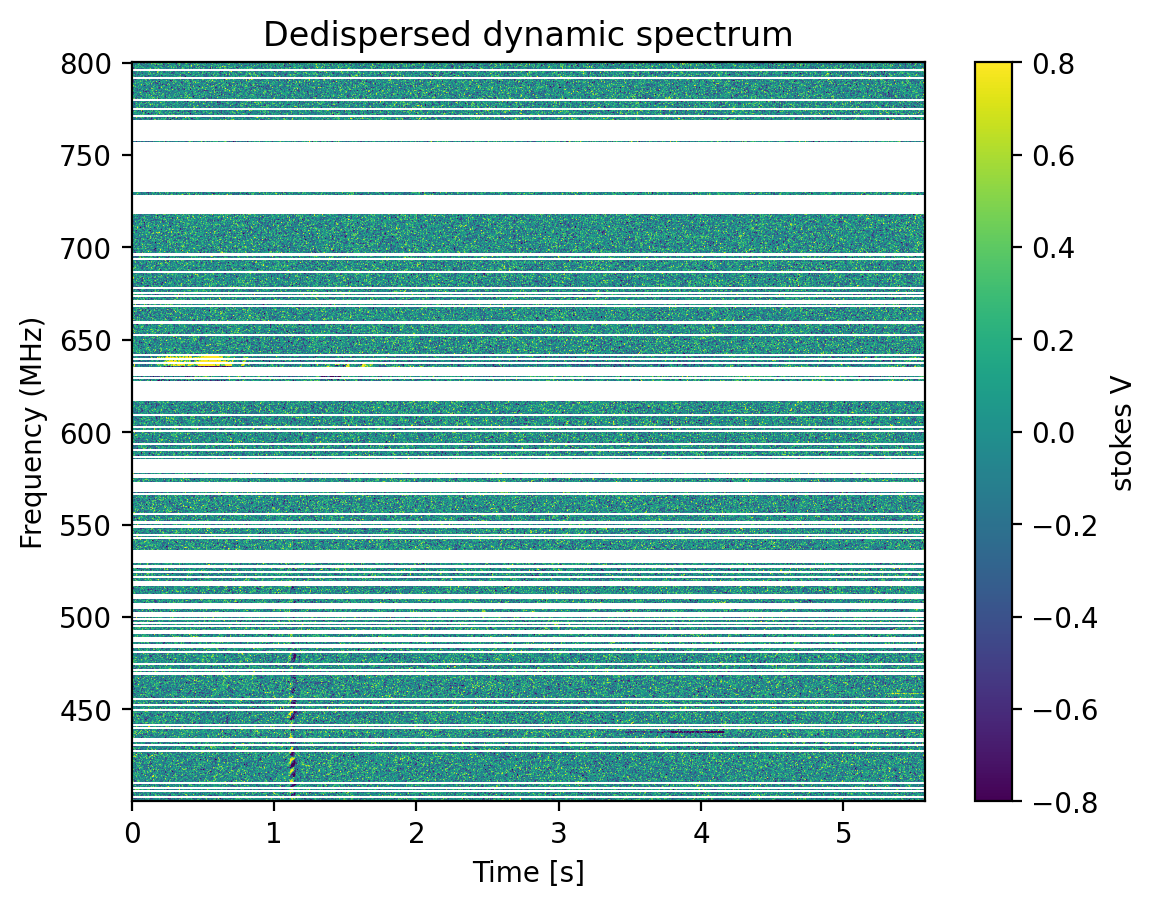

In [82]:
for i,label in zip(range(4), ["stokes I", "stokes Q", "stokes U", "stokes V"]):
    plt.figure(dpi=200)
    plt.imshow(
        stokes_norm_masked[i].T,
        aspect='auto',
        origin='lower',
        extent=[time.value[0], time.value[-1], freq.value[0], freq.value[-1]],
        norm=plt.cm.colors.Normalize(vmin=-0.8, vmax=0.8)
    )
    plt.xlabel("Time [s]")
    plt.ylabel("Frequency (MHz)")
    plt.title("Dedispersed dynamic spectrum")
    plt.colorbar(label=label)
    plt.show()

# dedispersing data

In [34]:
# fh for band 0
band0 = 5
file_list0 = sorted(glob.glob(f'{SOURCE_DIR}/CH-{band0}/20220826T064420Z_CHIME_vdif/*_0{band0}.vdif'))[start_frame:start_frame+1]
fh0 = vdif.open(file_list0, 'rs', sample_rate=SAMPLE_RATE)
fh0 = Reshape(fh0, (16,2,8))  # splitting frequency and polarization
fh0 = Transpose(fh0, (1,3,2))  # swapping axes so sub-bands and frequency channels are together
fh0 = Reshape(fh0, (128,2))  # combining sub-bands and frequency channels

# fh for band 1
band1 = 6
file_list1 = sorted(glob.glob(f'{SOURCE_DIR}/CH-{band1}/20220826T064420Z_CHIME_vdif/*_0{band1}.vdif'))[start_frame:start_frame+1]
fh1 = vdif.open(file_list1, 'rs', sample_rate=SAMPLE_RATE)
fh1 = Reshape(fh1, (16,2,8))  # splitting frequency and polarization
fh1 = Transpose(fh1, (1,3,2))  # swapping axes so sub-bands and frequency channels are together
fh1 = Reshape(fh1, (128,2))  # combining sub-bands and frequency channels

# fh for band 2
band2 = 7
file_list2 = sorted(glob.glob(f'{SOURCE_DIR}/CH-{band2}/20220826T064420Z_CHIME_vdif/*_0{band2}.vdif'))[start_frame:start_frame+1]
fh2 = vdif.open(file_list2, 'rs', sample_rate=SAMPLE_RATE)
fh2 = Reshape(fh2, (16,2,8))  # splitting frequency and polarization
fh2 = Transpose(fh2, (1,3,2))  # swapping axes so sub-bands and frequency channels are together
fh2 = Reshape(fh2, (128,2))  # combining sub-bands and frequency channels


# combine
fh = Concatenate((fh0, fh1, fh2), axis=1)

In [35]:
fh.shape

(50000, 384, 2)

In [15]:
# file_list = sorted(glob.glob(f'{SOURCE_DIR}/6/20220826T064420Z_CHIME_vdif/*_06.vdif'))[start_frame:start_frame+number_of_frames]
# fh = vdif.open(file_list, 'rs', sample_rate=SAMPLE_RATE)
# # file = f'{SOURCE_DIR}/6/20220826T064420Z_CHIME_vdif/0000000000_06.vdif'
# # fh = vdif.open(file, 'rs', sample_rate=SAMPLE_RATE) 
freq_array = np.linspace(500, 400, 128*2)

# # Reshape the data
# fh = Reshape(fh, (16,2,8))  # splitting frequency and polarization
# fh = Transpose(fh, (1,3,2))  # swapping axes so sub-bands and frequency channels are together
# fh = Reshape(fh, (128,2))  # combining sub-bands and frequency channels

# Dedisperse
fh = Dedisperse(
        fh,
        dm=DM,
        frequency=freq_array[:, None] * u.MHz,
        reference_frequency=np.max(freq_array)*u.MHz,
        sideband=1,
    )

# # Convert pol data to power & cross terms
fh = Power(fh, polarization=['XX', 'YY', 'XY', 'YX'])  # Shape (Ntimes, Nfreqs, 4)

# # Read data
data = fh.read()  # Shape (Ntimes, Nfreqs, Nterms)

In [16]:
I = data[:,:,0] + data[:,:,1]
Q = data[:,:,0] - data[:,:,1]  # |X|^2 - |Y|^2
U = 2 * data[:,:,2]  # 2 Re(XY*)
V = 2 * data[:,:,3]  # 2 Im(XY*)

full_stokes = np.array([I, Q, U, V])
full_stokes = np.flip(full_stokes, axis=2)  # flip freq axis to increasing order
freq = np.flip(freq_array, axis=0)

Dt = (fh.stop_time - fh.start_time).sec
time = np.linspace(0, Dt, I.shape[0])

In [19]:
# Get RFI mask using intensity data
ranges = [(529,535), (483, 483), (452,452)]
rfi_mask = get_rfi_mask(full_stokes[0], mean_treshhold=2., std_threshold=1.3, ranges=ranges, freqs=freq)

# Normalize & mask RFI channels
stokes_norm_masked = normalize_data(full_stokes.copy())
stokes_norm_masked[:,:,rfi_mask] = np.nan

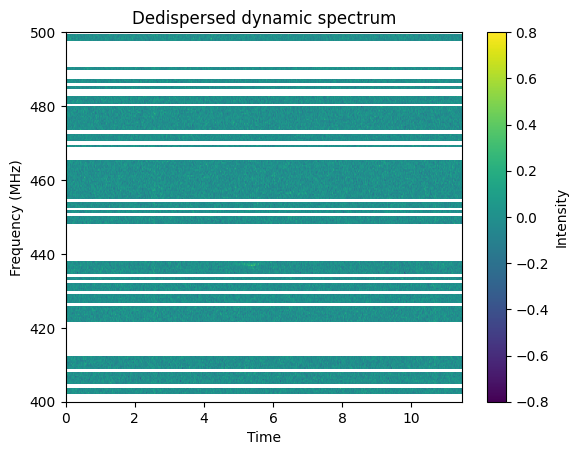

In [20]:
plt.imshow(
    stokes_norm_masked[0].T,
    aspect='auto',
    origin='lower',
    extent=[time[0], time[-1], freq[0], freq[-1]],
    norm=plt.cm.colors.Normalize(vmin=-0.8, vmax=0.8)
)
plt.xlabel("Time")
plt.ylabel("Frequency (MHz)")
plt.title("Dedispersed dynamic spectrum")
plt.colorbar(label="Intensity")
plt.show()